In [1]:
# Automatic reloading of imports
%load_ext autoreload
%autoreload 2

import sys
import os
import matplotlib.pyplot as plt
import numpy as np

# Put in the pyodine path on your machine here!
pyodine_path = '/Users/jaklusmeyer/SONG/pyodine'

sys.path.append(pyodine_path)

import pyodine
import pyodine_combine_vels  


import utilities_song_apo as utilities
Pars = utilities.timeseries_parameters.Timeseries_Parameters()

target_name = 'Sigma Draconis'


In [2]:
Pars = utilities.timeseries_parameters.Timeseries_Parameters()


        ),
    
    'song_3': Instrument(
                'SONG USA spectrograph (Apache Point Observatory)- 105.82042W',
                latitude=32.7803,
                longitude= 254.1796,  # West  
                altitude=2788  # Approximate elevation in meters

                Sig dra: HIP96100
                arcturus: HIP69673

In [3]:
bary_dict = {
    'star_name': 'HIP96100',
    #'star_ra': 0.0,          # in deg
    #'star_dec': 0.0,
    #'star_pmra': 0.0,        # in mas/yr
    #'star_pmdec': 0.0,
    #'star_rv0': 0.0,         # in m/s
    'instrument_lat': 32.7803,   # in deg
    'instrument_long': -105.8203, 
    'instrument_alt': 2788    # in m
}

From previous tutorial notebook where results go
data_base_dir = os.path.abspath(os.path.join(pyodine_path, '..', 'pyodine_aposong_data'))

# Output directories for plots, log files, and output pathnames for modelling results
plot_dir_parent = os.path.join(data_base_dir, f'{results_dir_name}/obs_results')

night = "UT260321"

data_path = '/Users/jaklusmeyer/SONG/reduce/'


target_name = "HD185144"          # template star
ostar_name  = "HR3982"            # hot star (LSF)
results_dir_name = "0007_sigdra_temp_results"

ostar_subdir         = "ostar"
#templatestar_subdir  = "templatestar"
#sciencestar_subdir   = "sciencestar"  
templatestar_subdir  = "HD185144_template"
sciencestar_subdir   = "HD185144_iodine"  
#
target_name = "Arcturus"          # template star
ostar_name  = "HR5191"            # hot star (LSF)
results_dir_name = "0005_allv2_largerchunkwidth_i2targetregion_Arc_temp_results"

In [4]:
from astropy.io import fits

# ====================================change these====================================================
night = "UT260321"
data_path = '/Users/jaklusmeyer/SONG/reduce/'

target_name = "HD185144"
ostar_name  = "HR3594"
#results_dir_name = "0007_sigdra_temp_results_v4_arcref" #where things will be saved, should be in data_path
results_dir_name = "0007_sigdra_temp_results_v5_o01_idealnight"

# ====================================should stay the same=============================================
data_base_dir = os.path.abspath(data_path)
plot_dir = os.path.join(data_base_dir, results_dir_name)

# === COLLECT RESULT FILES FROM MODELSTAROBS ===
parent_dir = os.path.join(plot_dir, "obs_results")
print(f"Results directory: {parent_dir}")
print(f"Exists: {os.path.isdir(parent_dir)}")

res_files = []
for d in sorted(os.listdir(parent_dir)):
    full_dir = os.path.join(parent_dir, d)
    if not os.path.isdir(full_dir):
        continue
    res1 = os.path.join(full_dir, f"{d}_res1.h5")
    if os.path.isfile(res1):
        res_files.append(res1)
    else:
        print(f"  Missing: {d}_res1.h5")

print(f"Found {len(res_files)} result files")

# === OUTPUT PATHS FOR VELOCITY ANALYSIS ===
plot_dir = os.path.join(data_base_dir, results_dir_name, "analysis", "vel_results")
os.makedirs(plot_dir, exist_ok=True)

comb_res_out = os.path.join(plot_dir, f"{target_name}_comb.h5")
vels_out = os.path.join(plot_dir, f"{target_name}_vels.h5")
error_file = os.path.join(plot_dir, "error.log")
info_file = os.path.join(plot_dir, "info.log")

print(f"Velocity plot dir: {plot_dir}")
print(f"Combined output: {comb_res_out}")

Results directory: /Users/jaklusmeyer/SONG/reduce/0007_sigdra_temp_results_v5_o01_idealnight/obs_results
Exists: True
  Missing: HD185144_ec_260307.0220_res1.h5
  Missing: HD185144_ec_260310.0210_res1.h5
Found 58 result files
Velocity plot dir: /Users/jaklusmeyer/SONG/reduce/0007_sigdra_temp_results_v5_o01_idealnight/analysis/vel_results
Combined output: /Users/jaklusmeyer/SONG/reduce/0007_sigdra_temp_results_v5_o01_idealnight/analysis/vel_results/HD185144_comb.h5


In [5]:
Results = pyodine_combine_vels.combine_velocity_results(
    Pars, res_files=res_files, plot_dir=plot_dir, comb_res_out=comb_res_out, 
    vels_out=vels_out, bary_dict=bary_dict, error_log=error_file, info_log=info_file)



Branch: master
Hash: c2a71ac
---------------------------
Weighting and combining velocities


100% (58 of 58) |########################| Elapsed Time: 0:00:00 Time:  0:00:00



Star: HD 185144

Velocity weighting and combination...
---------------------------------------------------
- Pyodine chunk combination (based on iSONG code) -
---------------------------------------------------

Weighting parameters used:
	good_chunks	3	4	5	6	7	8	9	10	11	12	13	14	
	good_orders	6	7	8	9	10	11	12	13	
	sig_limit_low	4.0
	sig_limit_up	1000.0
	sig_correct	1000.0
	reweight_alpha	1.8
	reweight_beta	8.0
	reweight_sigma	2.0
	weight_correct	0.01

Nr. of obs, chunks per obs: 58, 650

3351 NaN velocities (obs,chunk):
(0,2)  (0,3)  (0,4)  (0,5)  (0,8)  (0,9)  (0,12)  (0,20)  (0,25)  (0,31)  (0,46)  (0,47)  (0,55)  (0,69)  (0,82)  (0,83)  (0,96)  (0,101)  (0,104)  (0,105)  (0,112)  (0,115)  (0,118)  (0,119)  (0,120)  (0,124)  (0,130)  (0,138)  (0,141)  (0,180)  (0,194)  (0,197)  (0,201)  (0,206)  (0,221)  (0,225)  (0,231)  (0,250)  (0,265)  (0,280)  (0,289)  (0,331)  (0,337)  (0,341)  (0,347)  (0,399)  (0,404)  (0,423)  (0,424)  (0,425)  (0,432)  (0,434)  (0,436)  (0,441)  (0,444)  

/Users/jaklusmeyer/SONG/pyodine/pyodine/timeseries/combine_vels.py:289: RuntimeWarning: All-NaN slice encountered
  rv_precision2 = np.sqrt(1./np.nansum(np.nanmedian(chunk_weights, axis=0)))



Writing results to txt file: /Users/jaklusmeyer/SONG/reduce/0007_sigdra_temp_results_v5_o01_idealnight/analysis/vel_results/HD185144_vels.h5

Saving combined results to /Users/jaklusmeyer/SONG/reduce/0007_sigdra_temp_results_v5_o01_idealnight/analysis/vel_results/HD185144_comb.h5

Creating and saving analysis plots to:
	/Users/jaklusmeyer/SONG/reduce/0007_sigdra_temp_results_v5_o01_idealnight/analysis/vel_results

Observations with outlier RVs:

All done! Full work time: 4.976197719573975


In [6]:
Results = pyodine.timeseries.base.CombinedResults(
    os.path.join(plot_dir, f"{target_name}_comb.h5")
)


Loading combined results from /Users/jaklusmeyer/SONG/reduce/0007_sigdra_temp_results_v5_o01_idealnight/analysis/vel_results/HD185144_comb.h5


Loading combined results from /Users/jaklusmeyer/SONG/reduce/0007_sigdra_temp_results_v5_o01_idealnight/analysis/vel_results/HD185144_comb.h5


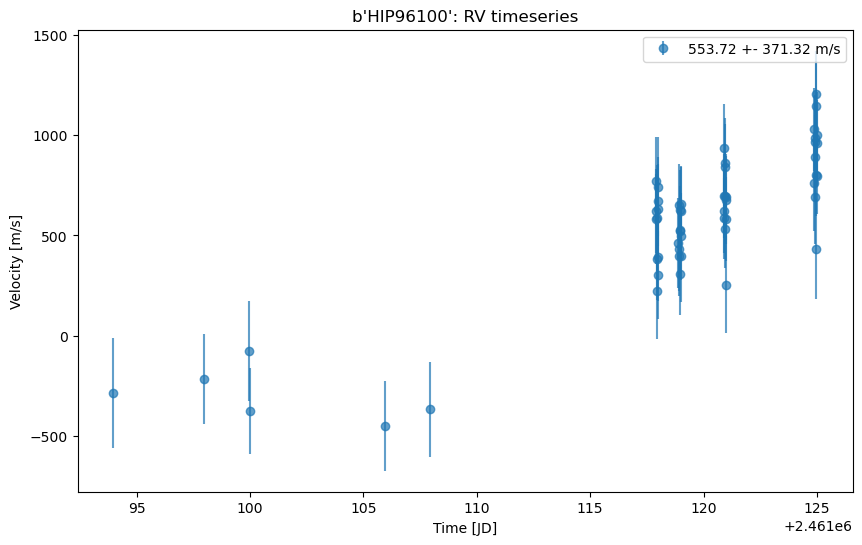

In [7]:
Results = pyodine.timeseries.base.CombinedResults(os.path.join(plot_dir, f'{target_name}_comb.h5'))
# The barycentric date, corrected bary date (shifted to solar system center),
# RV with barycentric correction, and RV uncertainty
bary_date      = Results.bary_date
bary_date_corr = Results.bary_date_corr
rv_bc          = Results.rv_bc
rv_err         = Results.rv_err

star_name = Results.info['star_name']    

mean_rv = np.mean(rv_bc)
std_rv = np.std(rv_bc)

mask = np.abs(rv_bc - mean_rv) < 2 * std_rv

# apply mask
bary_date_corr_clean = bary_date_corr[mask]
rv_bc_clean = rv_bc[mask]
rv_err_clean = rv_err[mask]


# And plot
fig = plt.figure(figsize=(10,6))
plt.errorbar(bary_date_corr_clean, rv_bc_clean, yerr=rv_err_clean, fmt='o', alpha=0.7,
             label='{:.2f} +- {:.2f} m/s'.format(np.mean(rv_bc_clean), np.std(rv_bc_clean)))
plt.legend()
plt.xlabel('Time [JD]')
plt.ylabel('Velocity [m/s]')
plt.title('{}: RV timeseries'.format(star_name))
plt.show()



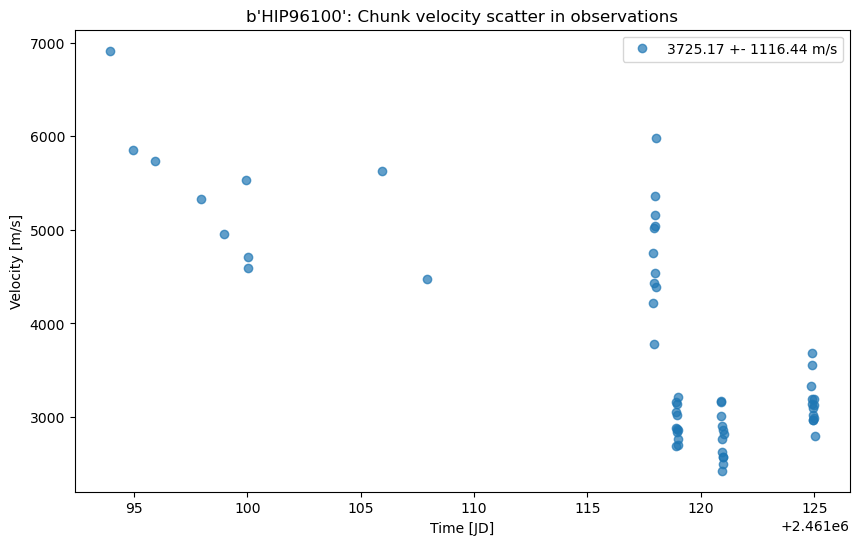

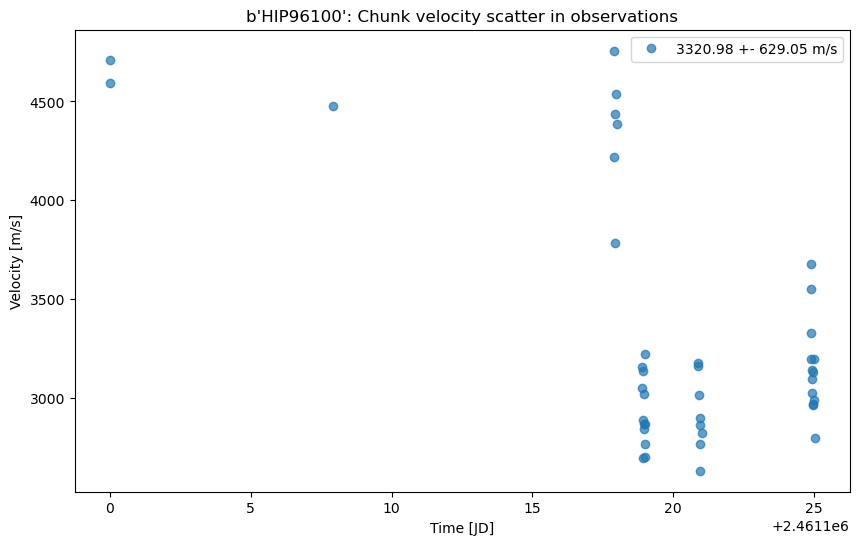

In [8]:
c2c_scatter = Results.c2c_scatter

fig = plt.figure(figsize=(10,6))
plt.plot(bary_date_corr, c2c_scatter, 'o', alpha=0.7,
        label='{:.2f} +- {:.2f} m/s'.format(np.mean(c2c_scatter), np.std(c2c_scatter)))
plt.legend()
plt.xlabel('Time [JD]')
plt.ylabel('Velocity [m/s]')
plt.title('{}: Chunk velocity scatter in observations'.format(star_name))
plt.show()

#create another filter for outliers and then plot
outlier_mask = np.abs(c2c_scatter - np.mean(c2c_scatter)) < 1 * np.std(c2c_scatter)
c2c_scatter_clean = c2c_scatter[outlier_mask]
bary_date_corr_clean = bary_date_corr[outlier_mask]
fig = plt.figure(figsize=(10,6))
plt.plot(bary_date_corr_clean, c2c_scatter_clean, 'o', alpha=0.7,
        label='{:.2f} +- {:.2f} m/s'.format(np.mean(c2c_scatter_clean), np.std(c2c_scatter_clean)))
plt.legend()
plt.xlabel('Time [JD]') 
plt.ylabel('Velocity [m/s]')
plt.title('{}: Chunk velocity scatter in observations'.format(star_name))
plt.show()      

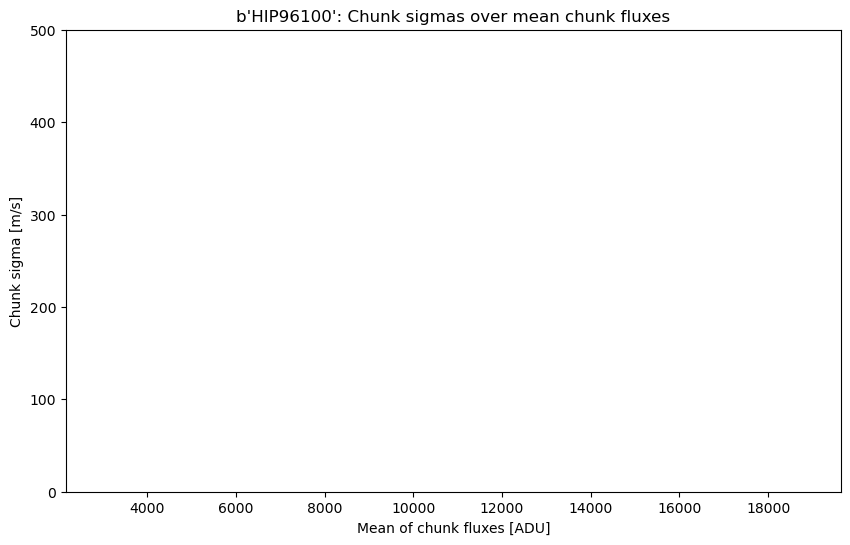

In [9]:
# Extract the median counts (medcnts) of each chunk in each observation, and average them over the observations
medcnts_mean = np.mean(Results.medcnts, axis=0)
# Extract the chunk sigmas
chunk_sigma  = Results.auxiliary['chunk_sigma']

fig = plt.figure(figsize=(10,6))
plt.plot(medcnts_mean, chunk_sigma, '.', alpha=0.7)
plt.xlabel('Mean of chunk fluxes [ADU]')
plt.ylabel('Chunk sigma [m/s]')
plt.ylim(0,500)
plt.title('{}: Chunk sigmas over mean chunk fluxes'.format(star_name))
plt.show()

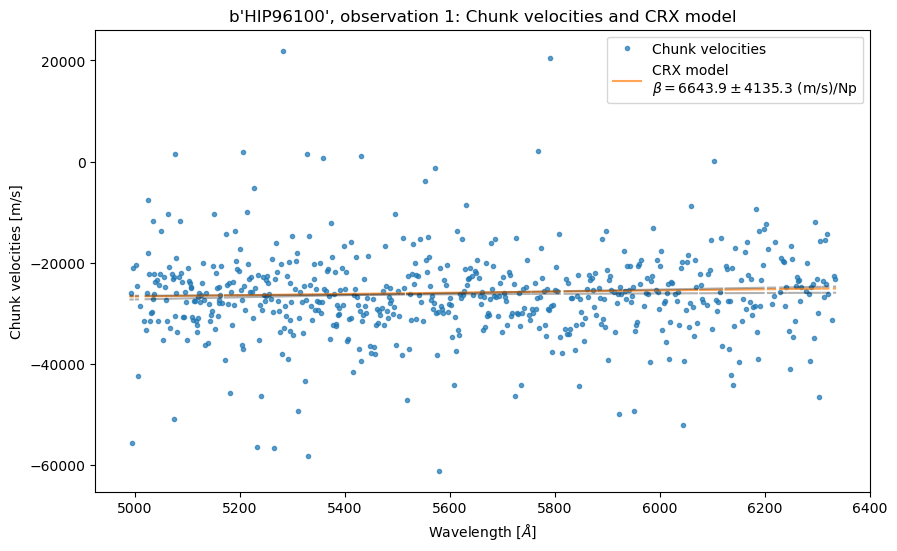

In [10]:
obs_ind = 1     # observation index

# The chunk wavelength intercepts of the observation
wave_int     = Results.params['wave_intercept'][obs_ind]
# The chunk velocities of the observation
velocity     = Results.params['velocity'][obs_ind]
# The weighted RV of the observation
rv_obs       = Results.rv[obs_ind]
# The CRX model effective wavelength of the RV (and error)
RV_wave      = Results.RV_wave[obs_ind]
RV_wave_err  = Results.RV_wave_err[obs_ind]
# The CRX model chromatic index (and error)
crx_obs      = Results.crx[obs_ind]
crx_obs_err  = Results.crx_err[obs_ind]

# Compute the velocities from the CRX model, along with upper and lower uncertainty
velocities_fit = pyodine.timeseries.combine_vels.velocity_from_chromatic_index(
    wave_int, rv_obs, RV_wave, crx_obs)
velocities_fit_lower = pyodine.timeseries.combine_vels.velocity_from_chromatic_index(
    wave_int, rv_obs-rv_err[obs_ind], RV_wave-RV_wave_err, crx_obs-crx_obs_err)
velocities_fit_upper = pyodine.timeseries.combine_vels.velocity_from_chromatic_index(
    wave_int, rv_obs+rv_err[obs_ind], RV_wave+RV_wave_err, crx_obs+crx_obs_err)

fig = plt.figure(figsize=(10,6))
plt.plot(wave_int, velocity, '.', alpha=0.7, label='Chunk velocities')
plt.plot(wave_int, velocities_fit, alpha=0.7, label='CRX model\n' + 
         r'$\beta={:.1f}\pm{:.1f}$ (m/s)/Np'.format(crx_obs, crx_obs_err))
plt.plot(wave_int, velocities_fit_lower, 'k', alpha=0.3)
plt.plot(wave_int, velocities_fit_upper, 'k', alpha=0.3)
plt.legend()
plt.xlabel(r'Wavelength [$\AA$]')
plt.ylabel('Chunk velocities [m/s]')
#plt.ylim(400., 1600.)
plt.title('{}, observation {}: Chunk velocities and CRX model'.format(star_name, obs_ind))
plt.show()

Testing different variables bary corp correct or not